# Análisis Comparativo de Gini y Entropía

Este notebook compara el Índice de Gini y la Entropía para dos variables categóricas relevantes en dos periodos de tiempo.

## 1. Importar librerías necesarias

In [1]:
# Importar librerías
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date
from pyspark.sql.types import NumericType
import os
import numpy as np
import matplotlib.pyplot as plt

## 2. Inicializar SparkSession

In [2]:
# Inicializar SparkSession
spark = SparkSession.builder.appName('GiniEntropiaComparativo').getOrCreate()

## 3. Cargar los datos desde la carpeta merge_pyspark

In [3]:
# Cargar todos los archivos Parquet de la carpeta merge_pyspark
parquet_folder = '../merge_pyspark'
parquet_files = [os.path.join(parquet_folder, f) for f in os.listdir(parquet_folder) if f.endswith('.parquet')]
df = spark.read.parquet(*parquet_files)
df.show(5)
df.printSchema()

+--------------------+----------+----------+------------------+----------------+------------+--------------------+---------------+-----------------+------------------+-----------------------+-------------------------+-----------------+-----------------+-------------------------+---------------------------+--------------------------+----------------------------+-------------+----------------+----------+----------------+--------------+----------------+----------+--------------------+----------------+------------------+--------------------+----+------+------------------+----------------------+---+--------------------+
|         customer_id|article_id|     Fecha|             price|sales_channel_id|product_code|           prod_name|product_type_no|product_type_name|product_group_name|graphical_appearance_no|graphical_appearance_name|colour_group_code|colour_group_name|perceived_colour_value_id|perceived_colour_value_name|perceived_colour_master_id|perceived_colour_master_name|department_no|

## 4. Preprocesamiento y conversión de fechas

In [ ]:
# Convertir la columna de fecha al formato adecuado y eliminar nulos
df = df.withColumn('fecha', to_date(col('fecha'), 'dd/MM/yyyy'))
df = df.dropna(subset=['fecha'])
df.select('fecha').show(5)

+----------+
|     fecha|
+----------+
|2019-11-28|
|2019-11-28|
|2019-02-10|
|2018-10-24|
|2019-02-10|
+----------+
only showing top 5 rows



## 5. División de los datos en dos conjuntos por rango de fechas

In [5]:
# Definir los rangos de fechas
from datetime import date
inicio_1 = date(2018, 9, 20)
fin_1 = date(2019, 12, 31)
inicio_2 = date(2020, 1, 1)
fin_2 = date(2020, 9, 22)

conjunto1 = df.filter((col('fecha') >= inicio_1) & (col('fecha') <= fin_1))
conjunto2 = df.filter((col('fecha') >= inicio_2) & (col('fecha') <= fin_2))
print('Conjunto 1:', conjunto1.count(), 'registros')
print('Conjunto 2:', conjunto2.count(), 'registros')

Conjunto 1: 20808192 registros
Conjunto 2: 10980132 registros


## 6. Selección de variables categóricas para el análisis

Se analizarán `product_group_name` y `department_name`.

In [6]:
# Variables categóricas a comparar
variables_categoricas = ['product_group_name', 'department_name']

def get_frequencies(df, colname):
    return df.groupBy(colname).count().toPandas()

freqs1 = {var: get_frequencies(conjunto1, var) for var in variables_categoricas}
freqs2 = {var: get_frequencies(conjunto2, var) for var in variables_categoricas}

for var in variables_categoricas:
    print(f'Frecuencias {var} - Conjunto 1:')
    print(freqs1[var])
    print(f'Frecuencias {var} - Conjunto 2:')
    print(freqs2[var])

Frecuencias product_group_name - Conjunto 1:
       product_group_name    count
0      Garment Lower body  4599637
1   Garment and Shoe care       64
2      Garment Upper body  8610456
3                Swimwear  1484678
4                    Bags     3162
5                   Items     2149
6                 Unknown    26017
7     Underwear/nightwear      473
8             Accessories  1092446
9               Furniture      456
10         Socks & Tights   481437
11               Cosmetic     1311
12              Underwear  1592224
13              Nightwear   241750
14                  Shoes   504204
15      Garment Full body  2167674
16       Interior textile       54
Frecuencias product_group_name - Conjunto 2:
       product_group_name    count
0      Garment Lower body  2446417
1   Garment and Shoe care      215
2      Garment Upper body  3942299
3              Stationery      229
4                Swimwear  1094544
5                    Bags     4151
6                   Items     3278


## 7. Cálculo del Índice de Gini y Entropía para ambas variables

In [7]:
# Funciones para calcular Gini y Entropía
def gini_index(counts):
    probs = counts / np.sum(counts)
    return 1 - np.sum(probs ** 2)

def entropy_index(counts):
    probs = counts / np.sum(counts)
    return -np.sum(probs * np.log2(probs + 1e-9))

resultados = {}
for var in variables_categoricas:
    counts1 = freqs1[var]['count'].values
    counts2 = freqs2[var]['count'].values
    resultados[var] = {
        'gini1': gini_index(counts1),
        'gini2': gini_index(counts2),
        'entropia1': entropy_index(counts1),
        'entropia2': entropy_index(counts2)
    }
    print(f"Variable: {var}")
    print(f"  Gini Conjunto 1: {resultados[var]['gini1']:.4f}")
    print(f"  Gini Conjunto 2: {resultados[var]['gini2']:.4f}")
    print(f"  Entropía Conjunto 1: {resultados[var]['entropia1']:.4f}")
    print(f"  Entropía Conjunto 2: {resultados[var]['entropia2']:.4f}")

Variable: product_group_name
  Gini Conjunto 1: 0.7541
  Gini Conjunto 2: 0.7846
  Entropía Conjunto 1: 2.4742
  Entropía Conjunto 2: 2.5852
Variable: department_name
  Gini Conjunto 1: 0.9719
  Gini Conjunto 2: 0.9664
  Entropía Conjunto 1: 5.9817
  Entropía Conjunto 2: 5.6777


## 8. Visualización comparativa de la distribución de ambas variables

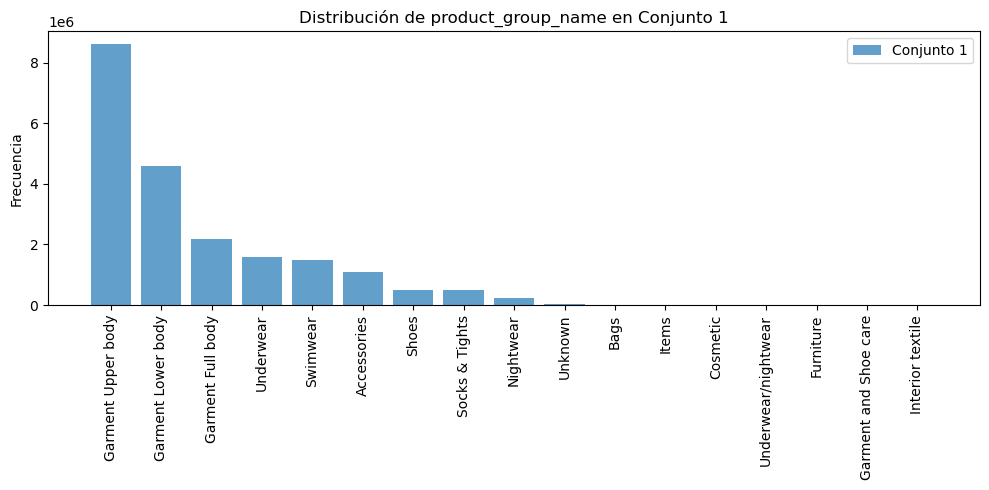

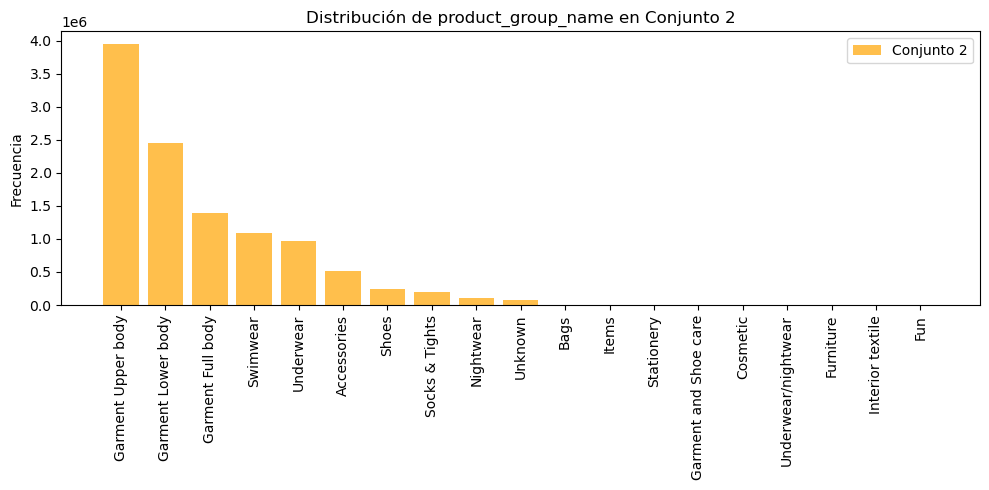

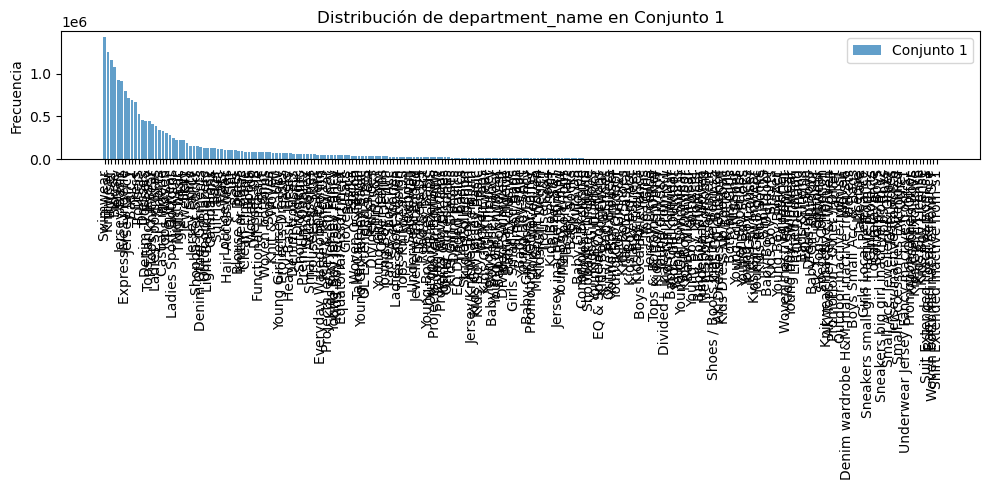

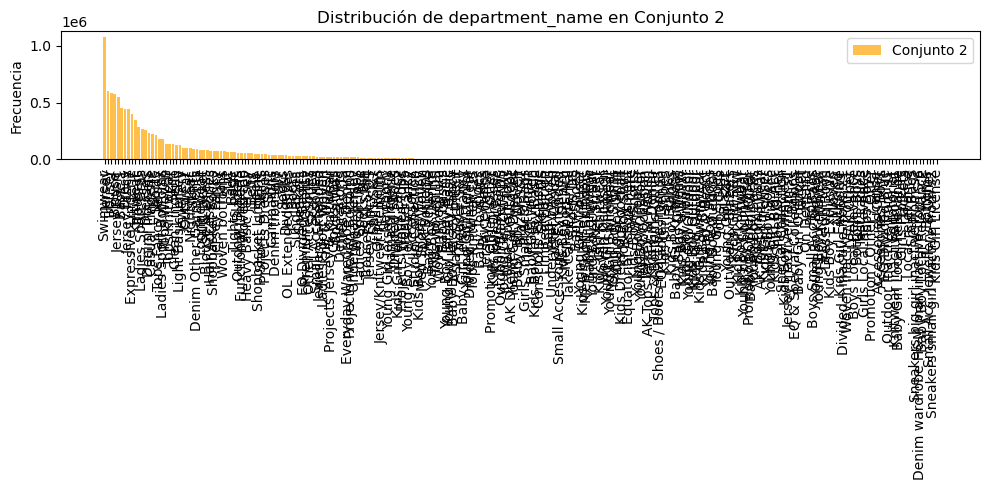

In [8]:
for var in variables_categoricas:
    plt.figure(figsize=(10,5))
    freq1_sorted = freqs1[var].sort_values('count', ascending=False)
    plt.bar(freq1_sorted[var], freq1_sorted['count'], alpha=0.7, label=f'Conjunto 1')
    plt.xticks(rotation=90)
    plt.title(f'Distribución de {var} en Conjunto 1')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10,5))
    freq2_sorted = freqs2[var].sort_values('count', ascending=False)
    plt.bar(freq2_sorted[var], freq2_sorted['count'], alpha=0.7, color='orange', label=f'Conjunto 2')
    plt.xticks(rotation=90)
    plt.title(f'Distribución de {var} en Conjunto 2')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 9. Interpretación comparativa de los resultados

- El **Índice de Gini** y la **Entropía** permiten comparar la diversidad y concentración de las variables categóricas seleccionadas en ambos periodos.
- Si una variable muestra mayor Gini y Entropía en un periodo, indica mayor diversidad y menor concentración en categorías específicas.